In [4]:
import time
import math
import matplotlib.pyplot as plt
import numpy as np


In [16]:
import time
def constant_time(arr):
    return arr[0]
def linear_time(arr):
    total = 0
    for x in arr:
        total += x
    return totalx
def quadratic_time(arr):
    count = 0
    for i in arr:
        for j in arr:
            count += 1
    return count
def logarithmic_time(n):
    while n > 1:
        n //= 2
input_sizes = [10, 100, 500, 1000]
times_O1, times_On, times_On2, times_Ologn = [], [], [], []
for n in input_sizes:
    arr = list(range(n))
    start = time.time()
    constant_time(arr)
    times_O1.append(time.time() - start)
    start = time.time()
    linear_time(arr)
    times_On.append(time.time() - start)
    start = time.time()
    quadratic_time(arr)
    times_On2.append(time.time() - start)
    start = time.time()
    logarithmic_time(n)
    times_Ologn.append(time.time() - start)
print("O(1):", times_O1)
print("O(n):", times_On)
print("O(n²):", times_On2)
print("O(log n):", times_Ologn)


O(1): [3.337860107421875e-06, 1.6689300537109375e-06, 1.430511474609375e-06, 2.6226043701171875e-06]
O(n): [2.86102294921875e-06, 8.344650268554688e-06, 4.1484832763671875e-05, 8.344650268554688e-05]
O(n²): [7.3909759521484375e-06, 0.0009195804595947266, 0.024585485458374023, 0.10810446739196777]
O(log n): [2.6226043701171875e-06, 3.5762786865234375e-06, 1.0251998901367188e-05, 7.3909759521484375e-06]


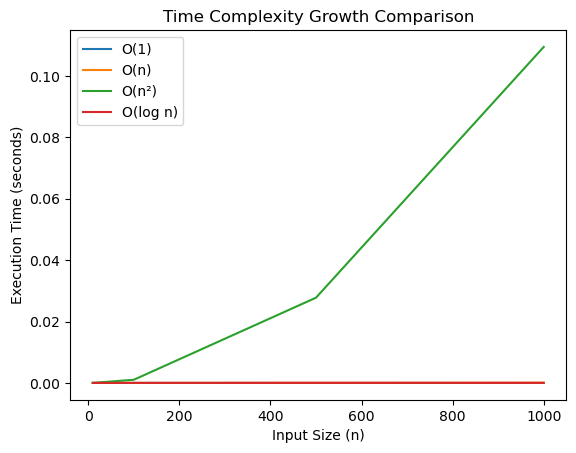

In [8]:
plt.plot(input_sizes, times_O1, label="O(1)")
plt.plot(input_sizes, times_On, label="O(n)")
plt.plot(input_sizes, times_On2, label="O(n²)")
plt.plot(input_sizes, times_Ologn, label="O(log n)")

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Time Complexity Growth Comparison")
plt.legend()
plt.show()


In [17]:
import time
def linear_search(arr, target):
    for i in range(len(arr)):
        if arr[i] == target:
            return i
    return -1
def binary_search(arr, target):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1
sizes = [10, 50, 100]
linear_times = []
binary_times = []

for n in sizes:
    arr = list(range(n))

    # Worst case
    start = time.time()
    linear_search(arr, -1)
    linear_times.append(time.time() - start)

    start = time.time()
    binary_search(arr, -1)
    binary_times.append(time.time() - start)

print("Linear Search Times:", linear_times)
print("Binary Search Times:", binary_times)


Linear Search Times: [6.4373016357421875e-06, 6.4373016357421875e-06, 8.344650268554688e-06]
Binary Search Times: [5.7220458984375e-06, 3.0994415283203125e-06, 2.86102294921875e-06]


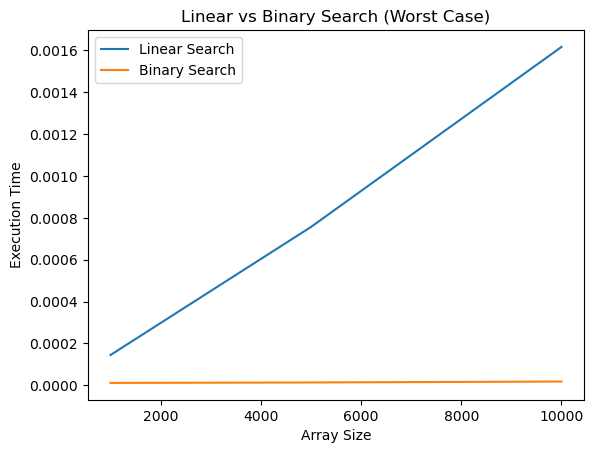

In [12]:
plt.plot(sizes, linear_times, label="Linear Search")
plt.plot(sizes, binary_times, label="Binary Search")

plt.xlabel("Array Size")
plt.ylabel("Execution Time")
plt.title("Linear vs Binary Search (Worst Case)")
plt.legend()
plt.show()



In [13]:
fact_calls = 0

def factorial(n):
    global fact_calls
    fact_calls += 1
    if n == 0:
        return 1
    return n * factorial(n - 1)

result = factorial(10)
print("Factorial:", result)
print("Function Calls:", fact_calls)


Factorial: 3628800
Function Calls: 11


In [23]:
fib_recursive_calls = 0

def fib_recursive(n):
    global fib_recursive_calls
    fib_recursive_calls += 1
    if n <= 1:
        return n
    return fib_recursive(n - 1) + fib_recursive(n - 2)

fib_recursive_calls = 0
result = fib_recursive(11)

print("Fibonacci (Recursive):", result)
print("Function Calls:", fib_recursive_calls)


Fibonacci (Recursive): 89
Function Calls: 287


In [12]:
def fib_dp(n):
    if n <= 1:
        return n

    dp = [0] * (n + 1)
    dp[1] = 1

    for i in range(2, n + 1):
        dp[i] = dp[i - 1] + dp[i - 2]

    return dp[n]
print("Fibonacci (DP):", fib_dp(10))


Fibonacci (DP): 55


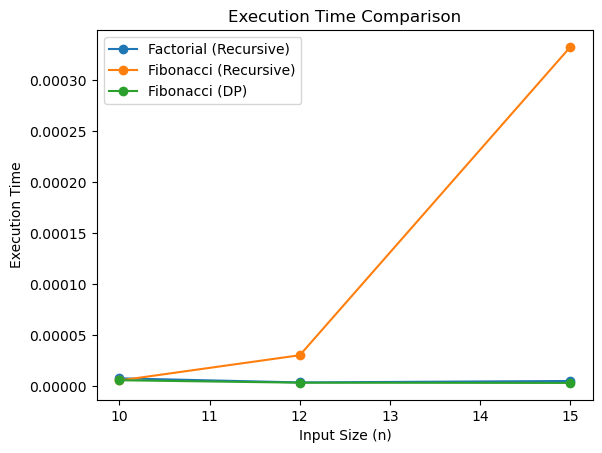

In [8]:
import matplotlib.pyplot as plt
n_values = [10, 12, 15]
plt.plot(n_values, fact_times, marker='o', label="Factorial (Recursive)")
plt.plot(n_values, fib_rec_times, marker='o', label="Fibonacci (Recursive)")
plt.plot(n_values, fib_dp_times, marker='o', label="Fibonacci (DP)")
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time")
plt.title("Execution Time Comparison")
plt.legend()
plt.show()


In [4]:
import time
factorial_calls = 0
def factorial(n):
    global factorial_calls
    factorial_calls += 1
    if n == 0:
        return 1
    return n * factorial(n-1)
fib_calls = 0
def fib_recursive(n):
    global fib_calls
    fib_calls += 1
    if n <= 1:
        return n
    return fib_recursive(n-1) + fib_recursive(n-2)
def fib_dp(n):
    if n <= 1:
        return n
    a, b = 0, 1
    for _ in range(2, n+1):
        a, b = b, a+b
    return b
print("n | FactCalls | FactTime | FibRecCalls | FibRecTime | FibDPTime")
print("-"*65)
for n in [10, 12, 15]:
    factorial_calls = 0
    start = time.time(); factorial(n)
    fact_time = time.time() - start
    fib_calls = 0
    start = time.time(); fib_recursive(n)
    fib_rec_time = time.time() - start
    start = time.time(); fib_dp(n)
    fib_dp_time = time.time() - start
    print(f"{n} | {factorial_calls:^9} | {fact_time:.6f} | "
          f"{fib_calls:^11} | {fib_rec_time:.6f} | {fib_dp_time:.6f}")

n | FactCalls | FactTime | FibRecCalls | FibRecTime | FibDPTime
-----------------------------------------------------------------
10 |    11     | 0.000010 |     177     | 0.000051 | 0.000007
12 |    13     | 0.000007 |     465     | 0.000136 | 0.000003
15 |    16     | 0.000008 |    1973     | 0.000955 | 0.000010


In [10]:
calls_rec1 = 0

def recurrence_1(n):
    global calls_rec1
    calls_rec1 += 1
    if n <= 1:
        return
    recurrence_1(n // 2)

calls_rec1 = 0
recurrence_1(102)
print("Recurrence 1 Calls:", calls_rec1)


Recurrence 1 Calls: 7


In [9]:
calls_rec2 = 0

def recurrence_2(n):
    global calls_rec2
    calls_rec2 += 1
    if n <= 1:
        return
    recurrence_2(n // 2)
    recurrence_2(n // 2)


calls_rec2 = 0
recurrence_2(102)
print("Recurrence 2 Calls:", calls_rec2)


Recurrence 2 Calls: 127


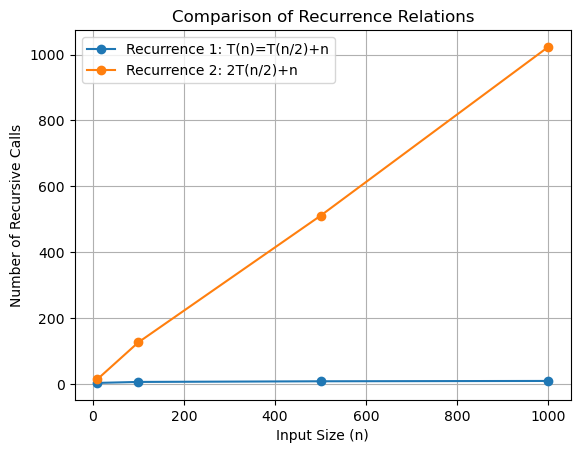

In [2]:
import matplotlib.pyplot as plt
n_values = [10, 100, 500, 1000]
rec1_calls = [4, 7, 9, 10]
rec2_calls = [15, 127, 511, 1023]

plt.plot(n_values, rec1_calls, marker='o', label="Recurrence 1: T(n)=T(n/2)+n")
plt.plot(n_values, rec2_calls, marker='o', label="Recurrence 2: 2T(n/2)+n")

plt.xlabel("Input Size (n)")
plt.ylabel("Number of Recursive Calls")
plt.title("Comparison of Recurrence Relations")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
import time
# Recurrence 1: T(n) = T(n/2) + n
calls_rec1 = 0
def recurrence_1(n):
    global calls_rec1
    calls_rec1 += 1
    if n <= 1:
        return
    recurrence_1(n // 2)
# Recurrence 2: T(n) = 2T(n/2) + n
calls_rec2 = 0
def recurrence_2(n):
    global calls_rec2
    calls_rec2 += 1
    if n <= 1:
        return
    recurrence_2(n // 2)
    recurrence_2(n // 2)
# Execution time analysis
n_values = [1, 10, 50, 100]

print("n | Rec1 Calls | Rec1 Time | Rec2 Calls | Rec2 Time")
print("-" * 60)

for n in n_values:
    calls_rec1 = 0
    start = time.time()
    recurrence_1(n)
    time_rec1 = time.time() - start

    calls_rec2 = 0
    start = time.time()
    recurrence_2(n)
    time_rec2 = time.time() - start

    print(f"{n:<4}| {calls_rec1:<10}| {time_rec1:.6f} | "
          f"{calls_rec2:<10}| {time_rec2:.6f}")


n | Rec1 Calls | Rec1 Time | Rec2 Calls | Rec2 Time
------------------------------------------------------------
1   | 1         | 0.000004 | 1         | 0.000002
10  | 4         | 0.000005 | 15        | 0.000006
50  | 6         | 0.000003 | 63        | 0.000025
100 | 7         | 0.000003 | 127       | 0.000042
